In [1]:
# 必要なモジュールをインポートする
import sqlite3
import requests
from bs4 import BeautifulSoup
import re
import time
import chardet  # エンコーディング検出用

# データベースの初期化またはアップデート
def init_db():
    conn = sqlite3.connect("hotels.db")  # データベース名前はhotels.db
    cursor = conn.cursor()
    
    # テーブルが存在しない場合は作成
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS hotel_info (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            hotel_name TEXT,
            price TEXT,
            walking_time TEXT
        )
    """)
    
    # `walking_time` カラムが存在しない場合は追加
    try:
        cursor.execute("ALTER TABLE hotel_info ADD COLUMN walking_time TEXT")
    except sqlite3.OperationalError:
        # カラムが既に存在する場合はエラーを無視
        pass

    conn.commit()  # データベースに変更を反映
    conn.close()  # データベースを閉じる

# データを挿入
def insert_data(hotel_name, price, walking_time):
    conn = sqlite3.connect("hotels.db")
    cursor = conn.cursor()
    cursor.execute("INSERT INTO hotel_info (hotel_name, price, walking_time) VALUES (?, ?, ?)", (hotel_name, price, walking_time))
    conn.commit()
    conn.close()

# 駅から徒歩時間を抽出する関数
def extract_walking_time(catch_phrase):
    match = re.search(r"徒歩(\d+)分", catch_phrase)
    if match:
        return f"{match.group(1)}分"
    else:
        return "情報なし"

# 指定したURLからスクレイピング
def scrape_url(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        # レスポンスのエンコーディングを自動検出
        detected_encoding = chardet.detect(response.content)["encoding"]

        # BeautifulSoupにエンコーディングを明示
        soup = BeautifulSoup(response.content, "html.parser", from_encoding=detected_encoding)
        hotel_items = soup.find_all("li", class_="p-yadoCassette p-searchResultItem")

        for item in hotel_items:
            try:
                # ホテル名
                hotel_name = item.find("h2", class_="p-searchResultItem__facilityName").text.strip()

                # 値段
                price = item.find("span", class_="p-searchResultItem__perPersonPrice").text.strip()

                # 徒歩時間をキャッチフレーズから抽出
                catch_phrase_tag = item.find("p", class_="p-searchResultItem__catchPhrase")
                if catch_phrase_tag:
                    catch_phrase = catch_phrase_tag.text.strip()
                    walking_time = extract_walking_time(catch_phrase)
                else:
                    walking_time = "情報なし"

                print(f"ホテル名: {hotel_name}, 値段: {price}, 徒歩時間: {walking_time}")

                # データベースに挿入
                insert_data(hotel_name, price, walking_time)

                # サーバー負荷を避けるためのスリープ
                time.sleep(1)
            except AttributeError:
                # 必要な要素が見つからない場合にスキップ
                continue
    else:
        print(f"Failed to fetch the page. Status code: {response.status_code}")

# メイン処理
if __name__ == "__main__":
    init_db()  # データベースの初期化またはアップデート

    # スクレイピングするURLリスト
    urls = [
        "https://www.jalan.net/uw/uwp2011/uww2011search.do?actionId=G&keyword=%82%DD%82%C8%82%C6%82%DD%82%E7%82%A2&dateUndecided=1&stayYear=2025&stayMonth=01&stayDay=14&adultNum=1&minPrice=0&maxPrice=999999&distCd=06&rootCd=7701&dispStartIndex=0&activeSort=0&screenId=UWW2011",
        "https://www.jalan.net/uw/uwp2011/uww2011search.do?actionId=G&keyword=%82%DD%82%C8%82%C6%82%DD%82%E7%82%A2&dateUndecided=1&stayYear=2025&stayMonth=01&stayDay=14&adultNum=1&minPrice=0&maxPrice=999999&distCd=06&rootCd=7701&dispStartIndex=30&activeSort=0&screenId=UWW2011",
        "https://www.jalan.net/uw/uwp2011/uww2011search.do?actionId=G&keyword=%82%DD%82%C8%82%C6%82%DD%82%E7%82%A2&dateUndecided=1&stayYear=2025&stayMonth=01&stayDay=14&adultNum=1&minPrice=0&maxPrice=999999&distCd=06&rootCd=7701&dispStartIndex=60&activeSort=0&screenId=UWW2011",
        "https://www.jalan.net/uw/uwp2011/uww2011search.do?actionId=G&keyword=%82%DD%82%C8%82%C6%82%DD%82%E7%82%A2&dateUndecided=1&stayYear=2025&stayMonth=01&stayDay=14&adultNum=1&minPrice=0&maxPrice=999999&distCd=06&rootCd=7701&dispStartIndex=90&activeSort=0&screenId=UWW2011"
    ]

    # 各URLを順にスクレイピング
    for url in urls:
        scrape_url(url)


ホテル名: 【ナビオス横浜】みなとみらい×赤レンガ☆360度極上夜景☆, 値段: 11,625円, 徒歩時間: 情報なし
ホテル名: 横浜みなとみらい　万葉倶楽部, 値段: 11,030円, 徒歩時間: 情報なし
ホテル名: 三井ガーデンホテル横浜みなとみらいプレミア, 値段: 18,400円, 徒歩時間: 情報なし
ホテル名: 京急EXホテルみなとみらい横浜（横浜シンフォステージ内）, 値段: 12,100円, 徒歩時間: 情報なし
ホテル名: ゲストハウス ＦＵＴＡＲＥＮＯ～横浜野毛みなとみらい～, 値段: 7,500円, 徒歩時間: 情報なし
ホテル名: ホテルセントラル横浜, 値段: 35,000円, 徒歩時間: 情報なし
ホテル名: ホテルリブマックス横浜元町駅前, 値段: 6,000円, 徒歩時間: 情報なし
ホテル名: ファーイーストビレッジホテル横浜, 値段: 10,200円, 徒歩時間: 5分
ホテル名: ホテルマイステイズ横浜, 値段: 6,400円, 徒歩時間: 情報なし
ホテル名: ホテルマイステイズ横浜関内, 値段: 6,800円, 徒歩時間: 1分
ホテル名: フレックステイイン桜木町, 値段: 6,400円, 徒歩時間: 5分
ホテル名: アパホテル＆リゾート〈横浜ベイタワー〉, 値段: 12,100円, 徒歩時間: 情報なし
ホテル名: 横浜桜木町ワシントンホテル, 値段: 10,550円, 徒歩時間: 1分
ホテル名: ザ・ゲートホテル横浜 by HULIC（2025年2月26日開業）, 値段: 23,335円, 徒歩時間: 情報なし
ホテル名: 横浜東急ＲＥＩホテル, 値段: 16,100円, 徒歩時間: 情報なし
ホテル名: 横浜マンダリンホテル, 値段: 22,000円, 徒歩時間: 情報なし
ホテル名: インターコンチネンタル横浜Ｐｉｅｒ ８, 値段: 88,700円, 徒歩時間: 情報なし
ホテル名: 横浜ベイホテル東急, 値段: 28,800円, 徒歩時間: 情報なし
ホテル名: リッチモンドホテル横浜馬車道(2023年7月リニューアルオープン), 値段: 8,500円, 徒歩時間: 情報なし
ホテル名: ダイワロイネットホテル横浜公園　2024年10月リニューアル, 値段: 21,430円, 徒歩時間: 情報なし
ホテ

In [2]:
#dbに格納できているか確認する
# データベースに接続
conn = sqlite3.connect('hotels.db')

# カーソルを作成
cur = conn.cursor()

# SQLコマンドを実行
cur.execute("SELECT * FROM hotel_info")

# 結果を取得して表示
results = cur.fetchall()
for row in results:
    print(row)

# 接続を閉じる
conn.close()

(1, '【ナビオス横浜】みなとみらい×赤レンガ☆360度極上夜景☆', '11,625円', '情報なし')
(2, '横浜みなとみらい\u3000万葉倶楽部', '11,030円', '情報なし')
(3, '三井ガーデンホテル横浜みなとみらいプレミア', '19,600円', '情報なし')
(4, '京急EXホテルみなとみらい横浜（横浜シンフォステージ内）', '11,600円', '情報なし')
(5, 'ゲストハウス ＦＵＴＡＲＥＮＯ～横浜野毛みなとみらい～', '7,500円', '情報なし')
(6, 'ホテルセントラル横浜', '35,000円', '情報なし')
(7, 'ホテルリブマックス横浜元町駅前', '5,500円', '情報なし')
(8, 'ファーイーストビレッジホテル横浜', '11,645円', '5分')
(9, 'ホテルマイステイズ横浜', '6,300円', '情報なし')
(10, 'フレックステイイン桜木町', '4,600円', '5分')
(11, '横浜桜木町ワシントンホテル', '8,900円', '1分')
(12, 'ホテルマイステイズ横浜関内', '6,300円', '1分')
(13, '横浜東急ＲＥＩホテル', '13,100円', '情報なし')
(14, 'アパホテル＆リゾート〈横浜ベイタワー〉', '12,600円', '情報なし')
(15, 'インターコンチネンタル横浜Ｐｉｅｒ ８', '47,700円', '情報なし')
(16, '横浜マンダリンホテル', '9,975円', '情報なし')
(17, '横浜ベイホテル東急', '31,000円', '情報なし')
(18, 'リッチモンドホテル横浜馬車道(2023年7月リニューアルオープン)', '8,500円', '情報なし')
(19, 'ザ・ゲートホテル横浜 by HULIC（2025年2月26日開業）', '23,335円', '情報なし')
(20, 'ダイワロイネットホテル横浜公園\u30002024年10月リニューアル', '7,400円', '情報なし')
(21, '相鉄フレッサイン横浜桜木町', '8,400円', '情報なし')
(22, '新横浜グレイスホテル', '9,000円', '1分')
(23, 'ホテル

In [3]:
import pandas as pd
import re

class DatabaseAnalyzer:
    def __init__(self, dbname):
        self.dbname = dbname

    def get_data(self, query):
        # データベースに接続
        conn = sqlite3.connect(self.dbname)

        # SQLクエリを発行してデータをPandasのデータフレームに読み込む
        df = pd.read_sql_query(query, conn)

        # 接続を閉じる
        conn.close()

        return df

    def clean_price_column(self, df):
        #正規表現を用いて徒歩時間から数値のみを抽出
        df['walking_time'] = df['walking_time'].apply(lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else None)
        # 正規表現を用いて価格列から数値のみを抽出
        df['price'] = df['price'].apply(lambda x: int(re.search(r'\d+', x.replace(',', '')).group()) if re.search(r'\d+', x) else None)
        return df

    def analyze_price(self, df):
        # クレンジングされたデータを使用して統計量を出力
        if df['price'].isnull().any():
            print("一部のデータに無効な価格情報が含まれていましたが、それらを除外して処理しました。")

        # 基本統計量を表示
        print(df['price'].describe())


# データベースアナライザーのインスタンスを作成
analyzer = DatabaseAnalyzer('hotels.db')

# データを取得
data = analyzer.get_data("SELECT * FROM hotel_info")

# 価格列をクレンジング
data = analyzer.clean_price_column(data)

# 価格データを分析
analyzer.analyze_price(data)


count      175.000000
mean     15288.714286
std      12911.056403
min       3800.000000
25%       7901.500000
50%       9975.000000
75%      17590.000000
max      88700.000000
Name: price, dtype: float64


In [4]:
#dfを定義する
df = data
# 価格帯を定義
bins = [0, 5000, 10000, 15000, 20000, 30000, 40000, 50000, float('inf')]
labels = ['0-5000', '5000-10000', '10000-15000', '15000-20000', '20000-30000', '30000-40000', '40000-50000', '50000+']

# 価格帯に基づいて新しい列を作成
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# 価格帯ごとにホテル数を集計
print(df['price_range'].value_counts().sort_index())

price_range
0-5000          7
5000-10000     81
10000-15000    34
15000-20000    16
20000-30000    16
30000-40000    12
40000-50000     4
50000+          5
Name: count, dtype: int64


In [5]:
# 価格が高い順に並べ替える
df = df.sort_values('price', ascending=False)

# データフレームを表示
df

,id,hotel_name,price,walking_time,price_range
104,105,インターコンチネンタル横浜Ｐｉｅｒ ８,88700,NaN,50000+
81,82,ザ・カハラ・ホテル＆リゾート 横浜,62490,NaN,50000+
112,113,ザ・カハラ・ホテル＆リゾート 横浜,62490,NaN,50000+
154,155,渋谷エクセルホテル東急,59650,NaN,50000+
143,144,オークウッドスイーツ横浜,55660,NaN,50000+
...,...,...,...,...,...
139,140,ヨコハマホステルヴィレッジ林会館,3960,5.0,0-5000
49,50,ヨコハマホステルヴィレッジ林会館,3960,5.0,0-5000
118,119,ＣＨＩＬＬＵＬＵ ＨＯＳＴＥＬ （チルル ホステル),3800,NaN,0-5000
50,51,Ｔａｂｉｓｔ ＭＡＹＵＤＡＭＡ ＣＡＢＩＮ,3800,1.0,0-5000


In [6]:
#価格が低い順に並べ変える
df = df.sort_values('price', ascending=True)

# データフレームを表示
df

,id,hotel_name,price,walking_time,price_range
29,30,ＣＨＩＬＬＵＬＵ ＨＯＳＴＥＬ （チルル ホステル),3800,NaN,0-5000
50,51,Ｔａｂｉｓｔ ＭＡＹＵＤＡＭＡ ＣＡＢＩＮ,3800,1.0,0-5000
118,119,ＣＨＩＬＬＵＬＵ ＨＯＳＴＥＬ （チルル ホステル),3800,NaN,0-5000
49,50,ヨコハマホステルヴィレッジ林会館,3960,5.0,0-5000
139,140,ヨコハマホステルヴィレッジ林会館,3960,5.0,0-5000
...,...,...,...,...,...
143,144,オークウッドスイーツ横浜,55660,NaN,50000+
154,155,渋谷エクセルホテル東急,59650,NaN,50000+
112,113,ザ・カハラ・ホテル＆リゾート 横浜,62490,NaN,50000+
81,82,ザ・カハラ・ホテル＆リゾート 横浜,62490,NaN,50000+


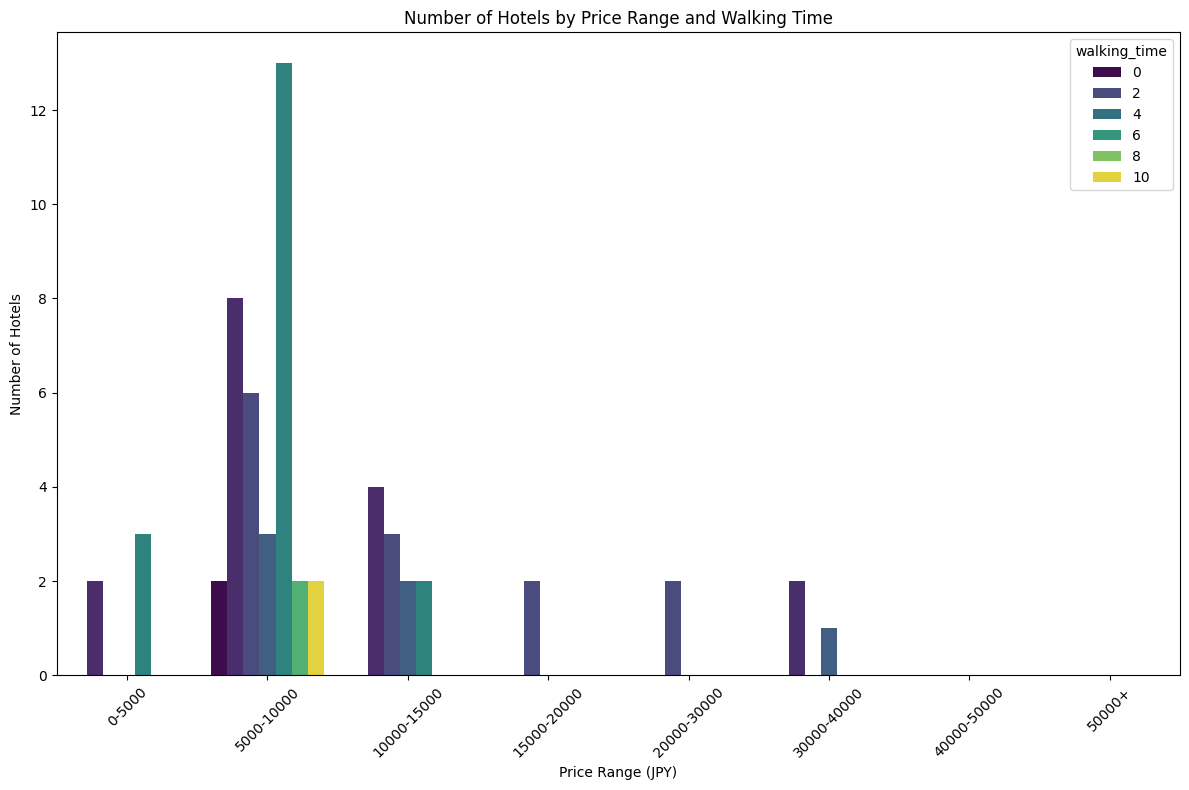

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

#徒歩時間と価格帯とホテルの数の関係を可視化
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='price_range', hue='walking_time', order=labels, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel('Price Range (JPY)')
plt.ylabel('Number of Hotels')
plt.title('Number of Hotels by Price Range and Walking Time')
plt.tight_layout()

plt.show()
